# Discrete Latent Geometry

Inspection notebook for CLI-generated discrete latent geometry diagnostics. The default preset is the promoted standard VQ tokenizer.

RVQ q2 was evaluated on research branches and is not part of the public baseline.


## Parameters


In [1]:
from __future__ import annotations

import json
import shlex
import subprocess
import sys
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import Image, Markdown, display

AUTO_SELECT_MODEL = True
MODEL_REGISTRY_PATH = "trained_models/model_registry.yaml"
MODEL_SELECTION_PROFILE = "balanced_market"
RUN_TRAINING = False
RUN_EVALUATION = False
RUN_HEAVY = True
ALLOW_MISSING_OUTPUTS = True

RUN_ANALYSIS = False


def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (
            candidate / "configs" / "experiments"
        ).exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPO_ROOT = find_repo_root()


def repo_path(path: str | Path) -> Path:
    candidate = Path(path).expanduser()
    if candidate.is_absolute():
        return candidate
    return (REPO_ROOT / candidate).resolve()


def display_path(path: str | Path) -> str:
    resolved = repo_path(path)
    try:
        return str(resolved.relative_to(REPO_ROOT))
    except ValueError:
        return str(resolved)


def load_json(path: str | Path) -> dict[str, Any] | None:
    resolved = repo_path(path)
    if not resolved.exists():
        return None
    return json.loads(resolved.read_text())


def print_command(command: list[str]) -> None:
    print(" ".join(shlex.quote(part) for part in command))


def maybe_run(command: list[str], *, enabled: bool, label: str) -> None:
    print(f"{label} command:")
    print_command(command)
    if enabled:
        subprocess.run(command, cwd=REPO_ROOT, check=True)
    else:
        print(f"{label} skipped; set RUN_ANALYSIS=True to execute it.")


print(f"Repository root: {REPO_ROOT}")
EXPERIMENT_ID = "sp500_vix"
PRESET = "standard_vq"
BASE_DATA_DIR = Path("data/processed")

PRESETS = {
    "standard_vq": {
        "label": "Standard VQ promoted baseline",
        "config": Path("configs/experiments/sp500_vix_causal_vq_tokenizer.yaml"),
        "tokenizer_dir": Path(
            "outputs/sp500_vix_discrete/tokenizer/sp500_vix_causal_vq_tokenizer_seed0"
        ),
        "token_data_dir": Path(
            "outputs/sp500_vix_discrete/token_prior/tokens_codebook64_codebookdim16"
        ),
        "output_dir": Path("outputs/latent_geometry/sp500_vix_standard_vq"),
    },
}

if PRESET not in PRESETS:
    raise ValueError(f"Unknown PRESET: {PRESET}")

SELECTED = PRESETS[PRESET]
CONFIG_PATH = SELECTED["config"]
TOKENIZER_DIR = SELECTED["tokenizer_dir"]
TOKEN_DATA_DIR = SELECTED["token_data_dir"]
OUTPUT_DIR = SELECTED["output_dir"]
print(SELECTED["label"])
print("output_dir:", display_path(OUTPUT_DIR))

Repository root: /home/georgios-vourvachakis/Desktop/TimeCausalVQVAE
Standard VQ promoted baseline
output_dir: outputs/latent_geometry/sp500_vix_standard_vq


## Registered Model Selection


In [2]:
from time_causal_vae.experiments.model_registry import load_registry, select_registered_model

REGISTERED_MODEL = None
DISCRETE_CHECKPOINT_CONVENTION = None
if AUTO_SELECT_MODEL:
    registry = load_registry(repo_path(MODEL_REGISTRY_PATH))
    REGISTERED_MODEL = select_registered_model(
        registry,
        experiment=EXPERIMENT_ID,
        family="discrete",
        profile=MODEL_SELECTION_PROFILE,
    )
    if REGISTERED_MODEL.tokenizer_config:
        TOKENIZER_CONFIG = REGISTERED_MODEL.tokenizer_config
    if REGISTERED_MODEL.prior_config:
        TOKEN_PRIOR_CONFIG = REGISTERED_MODEL.prior_config
    if REGISTERED_MODEL.tokenizer_config and "CONFIG_PATH" in globals():
        CONFIG_PATH = Path(REGISTERED_MODEL.tokenizer_config)
    DISCRETE_CHECKPOINT_CONVENTION = REGISTERED_MODEL.checkpoint_paths.get("checkpoint_convention")
    print(
        f"Registered discrete model: {REGISTERED_MODEL.candidate_id} "
        f"({REGISTERED_MODEL.selected_by})"
    )
    print(f"Tokenizer config: {display_path(TOKENIZER_CONFIG)}")
    print(f"Prior config: {display_path(TOKEN_PRIOR_CONFIG)}")
    if DISCRETE_CHECKPOINT_CONVENTION:
        print(f"Checkpoint convention: {DISCRETE_CHECKPOINT_CONVENTION}")
    if not any(value is True for value in REGISTERED_MODEL.local_checkpoint_status.values()):
        print(
            "No local tokenizer/prior checkpoint was resolved by the registry. Keep RUN_HEAVY, "
            "RUN_TRAINING, and RUN_EVALUATION disabled until local artefacts are available."
        )
    if REGISTERED_MODEL.metrics:
        display(pd.DataFrame([REGISTERED_MODEL.metrics]))
    if REGISTERED_MODEL.missing_metrics:
        print("Missing metrics:", ", ".join(REGISTERED_MODEL.missing_metrics))
else:
    print("AUTO_SELECT_MODEL=False; using notebook-local config defaults.")

Registered discrete model: conditional_standard_vq_additive_ar (explicit_selected)
Tokenizer config: configs/experiments/sp500_vix_causal_vq_tokenizer.yaml
Prior config: configs/experiments/sp500_vix_causal_token_prior_additive.yaml
Checkpoint convention: outputs/sp500_vix_discrete/
No local tokenizer/prior checkpoint was resolved by the registry. Keep RUN_HEAVY, RUN_TRAINING, and RUN_EVALUATION disabled until local artefacts are available.


,mmd,swd,returns_wasserstein,terminal_wasserstein,volatility_wasserstein,drawdown_wasserstein,return_ac_l1,squared_return_ac_l1,balanced_score,prior_eval_cross_entropy,prior_eval_perplexity,prior_eval_accuracy,tokenizer_perplexity,tokenizer_active_codes,token_dataset_perplexity,token_dataset_active_codes
0,0.254177,0.013836,0.001012,0.010252,0.001504,0.010957,0.055395,0.039584,0.04834,0.914807,2.507927,0.647449,29.406109,62.0,39.055717,63.0


Missing metrics: notebook_reproduction


## Artefact Check


In [3]:
required_inputs = {
    "CONFIG_PATH": CONFIG_PATH,
    "TOKENIZER_DIR": TOKENIZER_DIR,
    "TOKEN_DATA_DIR": TOKEN_DATA_DIR,
    "BASE_DATA_DIR": BASE_DATA_DIR,
}
missing = {name: path for name, path in required_inputs.items() if not repo_path(path).exists()}
if missing:
    print("Missing required artefacts for a real latent-geometry run:")
    for name, path in missing.items():
        print(f"  - {name}: {display_path(path)}")
else:
    print("All configured inputs are present.")
    for name, path in required_inputs.items():
        print(f"  - {name}: {display_path(path)}")

All configured inputs are present.
  - CONFIG_PATH: configs/experiments/sp500_vix_causal_vq_tokenizer.yaml
  - TOKENIZER_DIR: outputs/sp500_vix_discrete/tokenizer/sp500_vix_causal_vq_tokenizer_seed0
  - TOKEN_DATA_DIR: outputs/sp500_vix_discrete/token_prior/tokens_codebook64_codebookdim16
  - BASE_DATA_DIR: data/processed


## Optional Analysis Run


In [4]:
analysis_command = [
    sys.executable,
    "scripts/analyze_discrete_latent_geometry.py",
    "--config",
    display_path(CONFIG_PATH),
    "--tokenizer-dir",
    display_path(TOKENIZER_DIR),
    "--token-data-dir",
    display_path(TOKEN_DATA_DIR),
    "--output-dir",
    display_path(OUTPUT_DIR),
    "--base-data-dir",
    display_path(BASE_DATA_DIR),
    "--plot-voronoi",
]
if missing and RUN_ANALYSIS:
    print("RUN_ANALYSIS=True, but required inputs are missing. Resolve paths first.")
else:
    maybe_run(analysis_command, enabled=RUN_ANALYSIS, label="Latent geometry")

Latent geometry command:
/home/georgios-vourvachakis/Desktop/TimeCausalVQVAE/.venv/bin/python scripts/analyze_discrete_latent_geometry.py --config configs/experiments/sp500_vix_causal_vq_tokenizer.yaml --tokenizer-dir outputs/sp500_vix_discrete/tokenizer/sp500_vix_causal_vq_tokenizer_seed0 --token-data-dir outputs/sp500_vix_discrete/token_prior/tokens_codebook64_codebookdim16 --output-dir outputs/latent_geometry/sp500_vix_standard_vq --base-data-dir data/processed --plot-voronoi
Latent geometry skipped; set RUN_ANALYSIS=True to execute it.


## Numeric Summary


In [5]:
summary = load_json(OUTPUT_DIR / "codebook_geometry_summary.json")
if summary is None:
    print(
        f"No geometry summary found at {display_path(OUTPUT_DIR / 'codebook_geometry_summary.json')}"
    )
else:
    usage = summary.get("usage", {})
    geometry = summary.get("geometry", {})
    metadata = summary.get("metadata", {})
    display(
        pd.DataFrame(
            [
                {
                    "quantizer_type": metadata.get("quantizer_type"),
                    "embedding_shape": geometry.get("embedding_shape"),
                    "active_codes": usage.get("active_code_count"),
                    "perplexity": usage.get("codebook_perplexity"),
                    "entropy": usage.get("entropy") or usage.get("index_entropy"),
                }
            ]
        )
    )
    if summary.get("condition_buckets"):
        display(Markdown("### VIX-bucket usage"))
        display(pd.DataFrame(summary["condition_buckets"]))

,quantizer_type,embedding_shape,active_codes,perplexity,entropy
0,vector,"[64, 16]",63,39.055717,3.664989


### VIX-bucket usage

,active_code_count,active_code_ratio,bucket_index,bucket_label,code_usage_counts,code_usage_probability,codebook_perplexity,condition_max,condition_mean,condition_min,index_entropy,n_samples
0,53,0.828125,0,very_low,"[0, 1019, 224, 0, 0, 6301, 126, 198, 44, 432, ...","[0.0, 0.01727704331278801, 0.00379789760336279...",28.486874,0.155521,0.139454,0.110533,3.349443,983
1,56,0.875000,1,low,"[0, 971, 322, 22, 0, 4851, 272, 262, 12, 450, ...","[0.0, 0.016463207080960274, 0.0054594776593148...",32.337715,0.180070,0.166972,0.155521,3.476234,983
2,58,0.906250,2,mid,"[2, 825, 306, 62, 0, 4056, 285, 240, 58, 808, ...","[3.3909800549736246e-05, 0.013987792655825615,...",35.602974,0.217560,0.197613,0.180312,3.572429,983
3,60,0.937500,3,high,"[60, 589, 38, 280, 0, 2646, 533, 264, 226, 185...","[0.0010172940092161298, 0.009986435994505882, ...",40.414406,0.275124,0.244824,0.217560,3.699186,983
4,63,0.984375,4,very_high,"[734, 302, 108, 1390, 468, 1468, 2350, 216, 46...","[0.012457569129765034, 0.005125593859702349, 0...",43.821861,1.000000,0.355608,0.275366,3.780133,982


## Generated Plots


,plot,path,exists
0,codebook_projection.png,outputs/latent_geometry/sp500_vix_standard_vq/...,True
1,codebook_usage_projection.png,outputs/latent_geometry/sp500_vix_standard_vq/...,True
2,vix_bucket_code_usage.png,outputs/latent_geometry/sp500_vix_standard_vq/...,True
3,token_trajectory_examples.png,outputs/latent_geometry/sp500_vix_standard_vq/...,True
4,codebook_voronoi.png,outputs/latent_geometry/sp500_vix_standard_vq/...,True
5,codebook_nearest_region.png,outputs/latent_geometry/sp500_vix_standard_vq/...,False


### `codebook_projection.png`

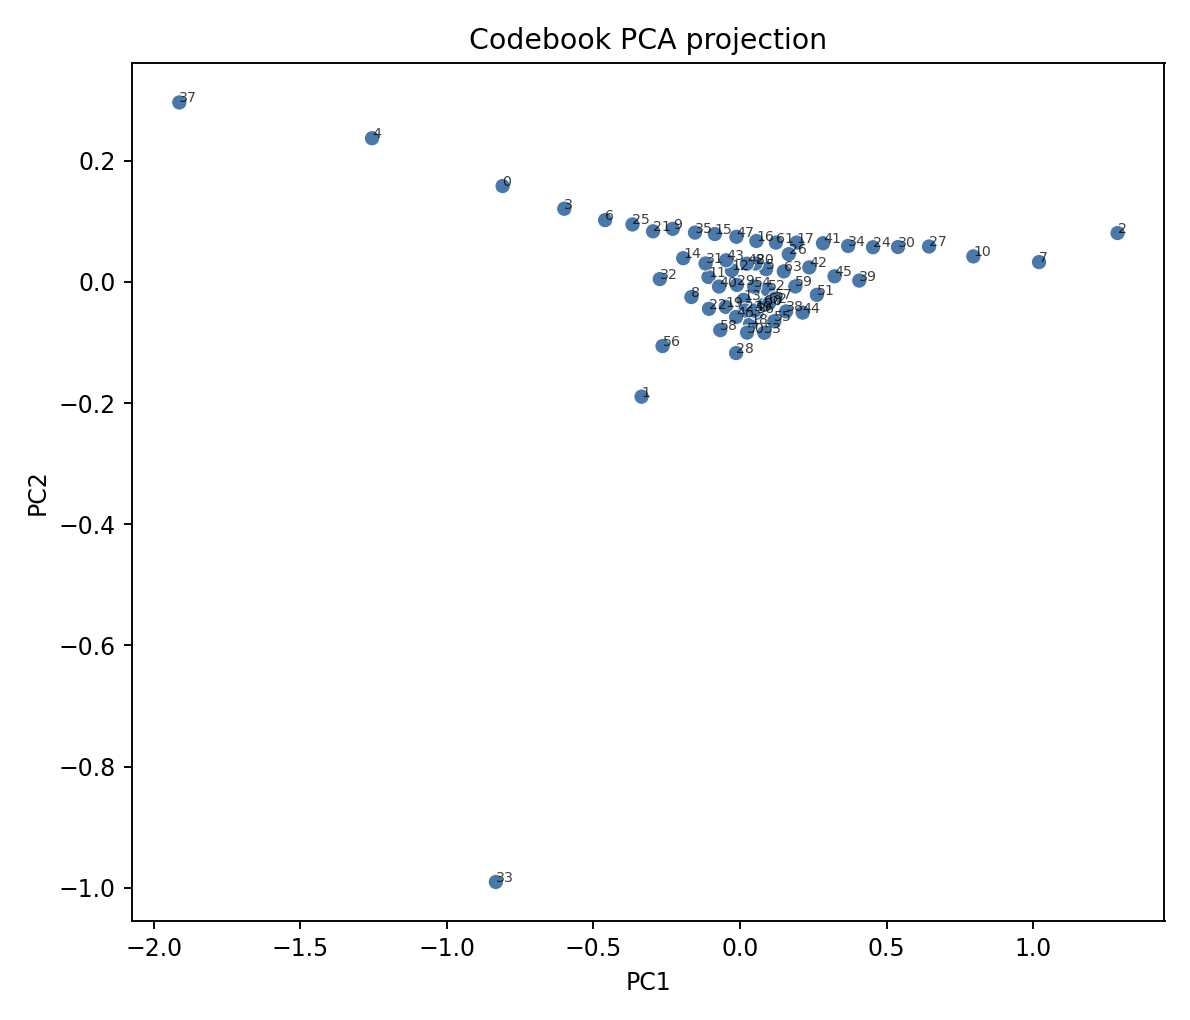

### `codebook_usage_projection.png`

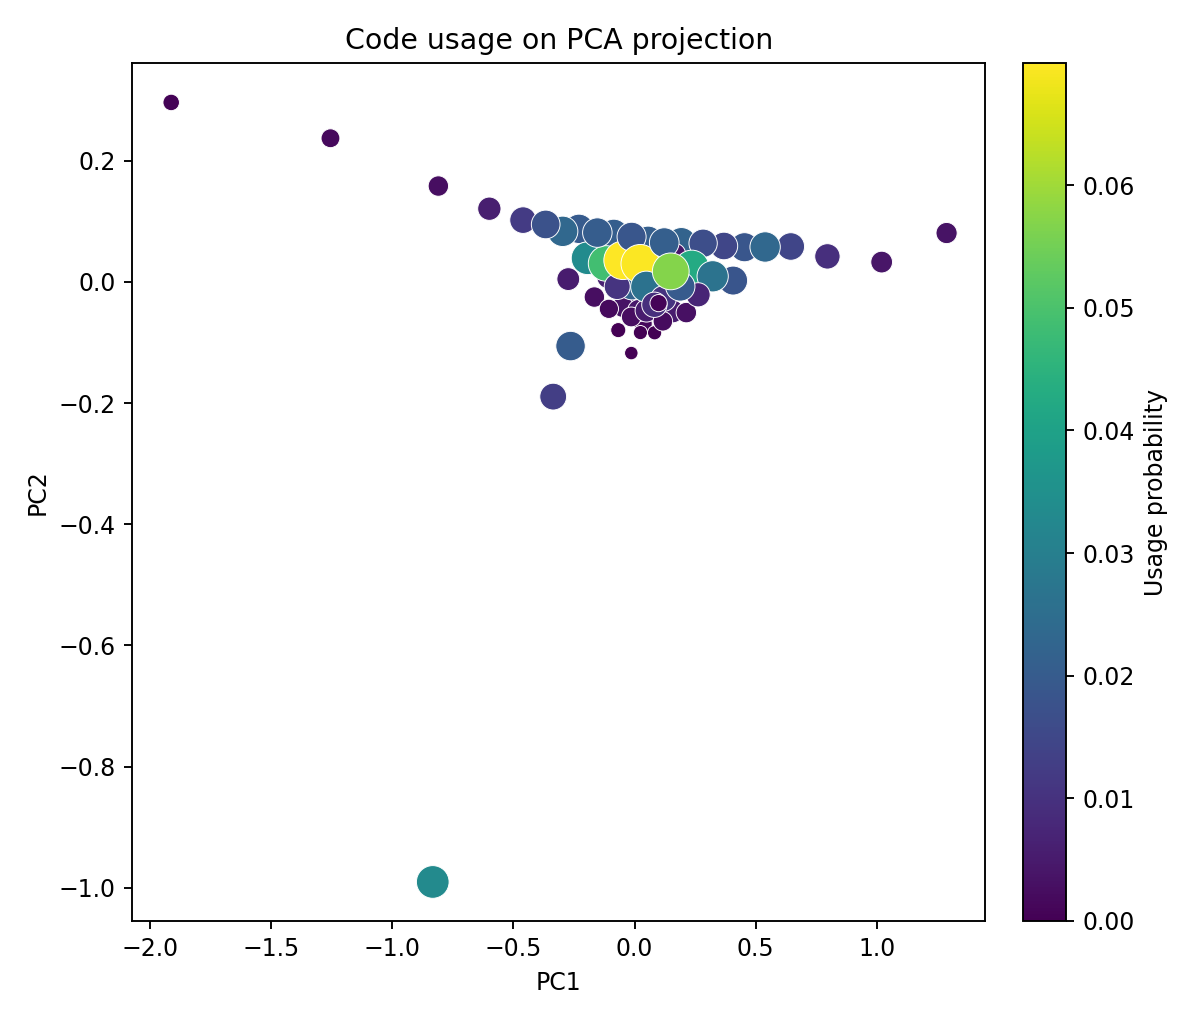

### `vix_bucket_code_usage.png`

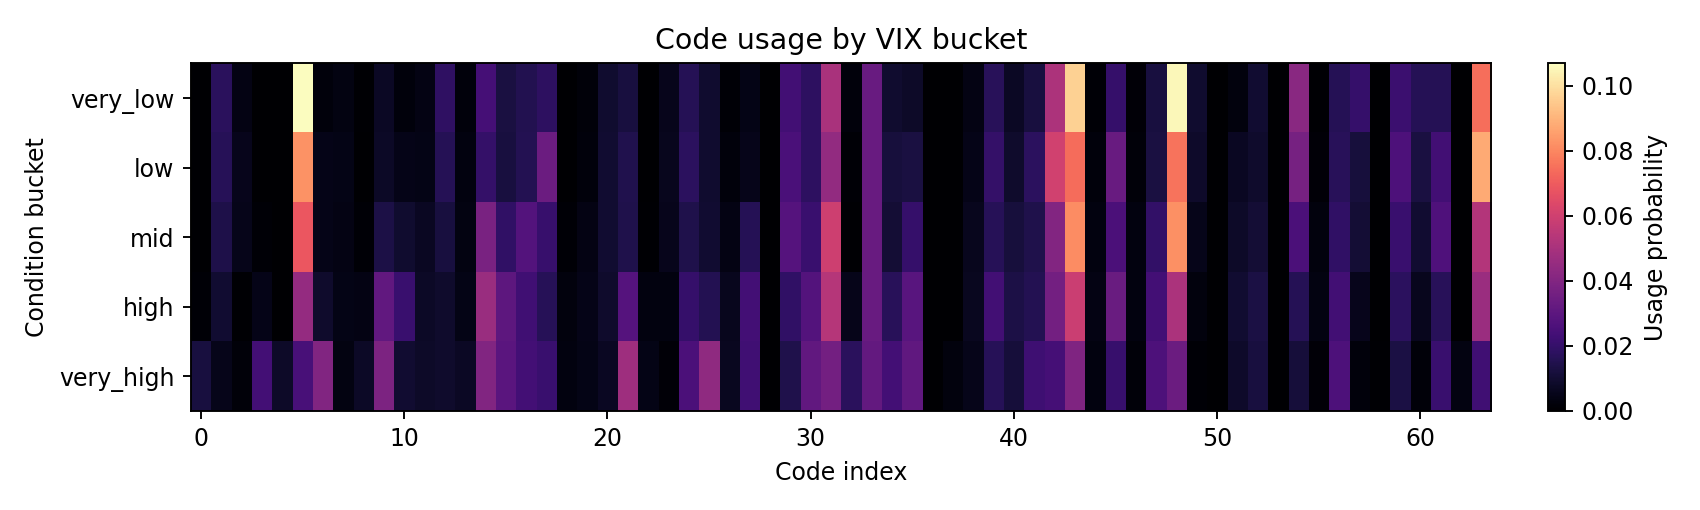

### `token_trajectory_examples.png`

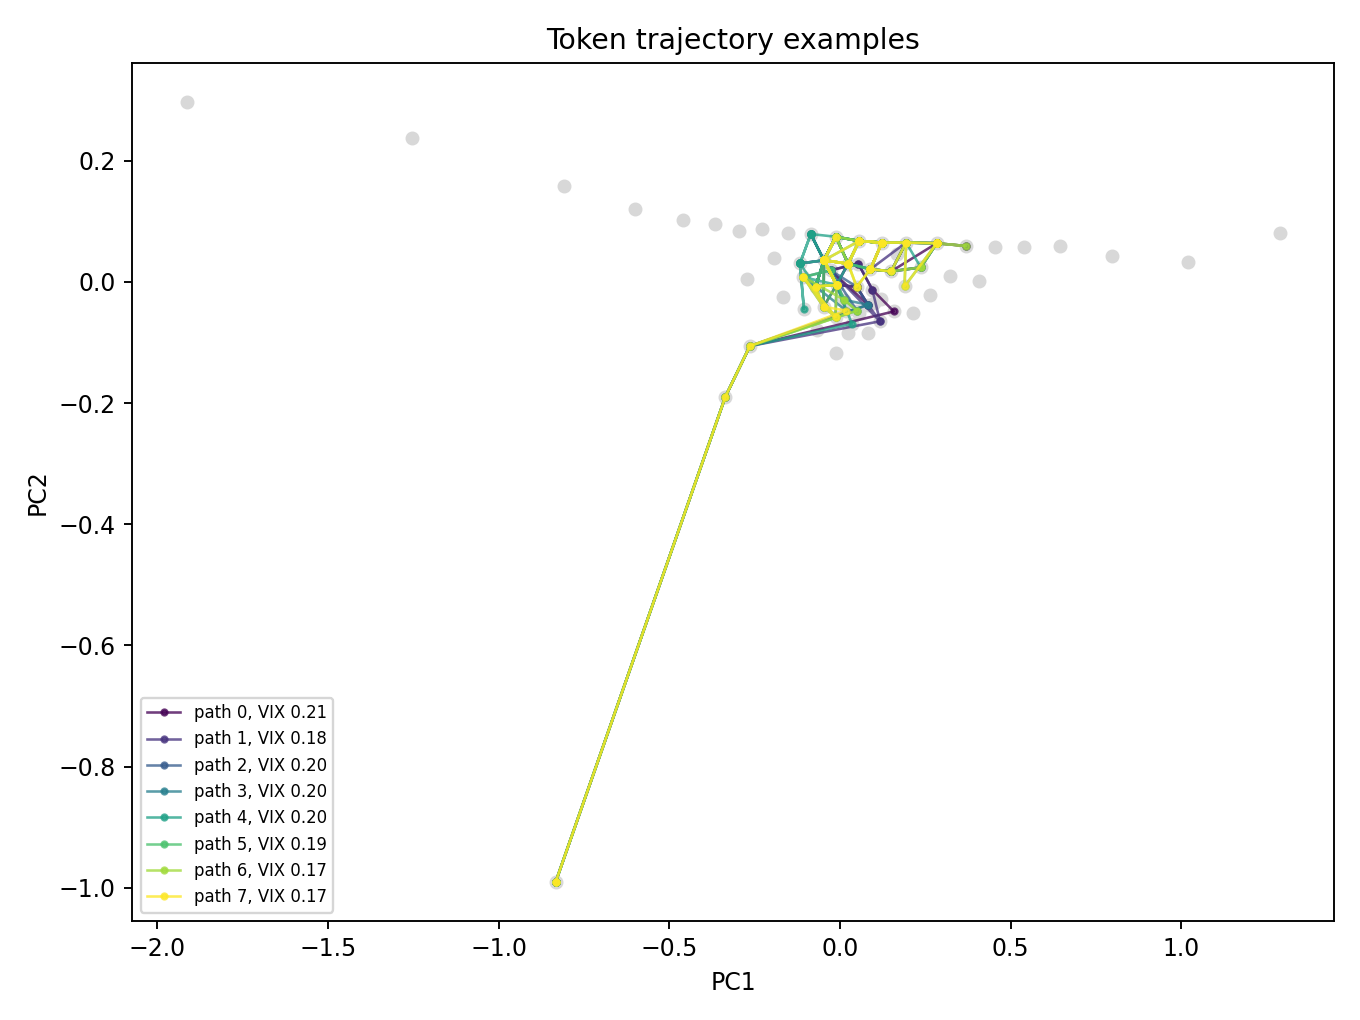

### `codebook_voronoi.png`

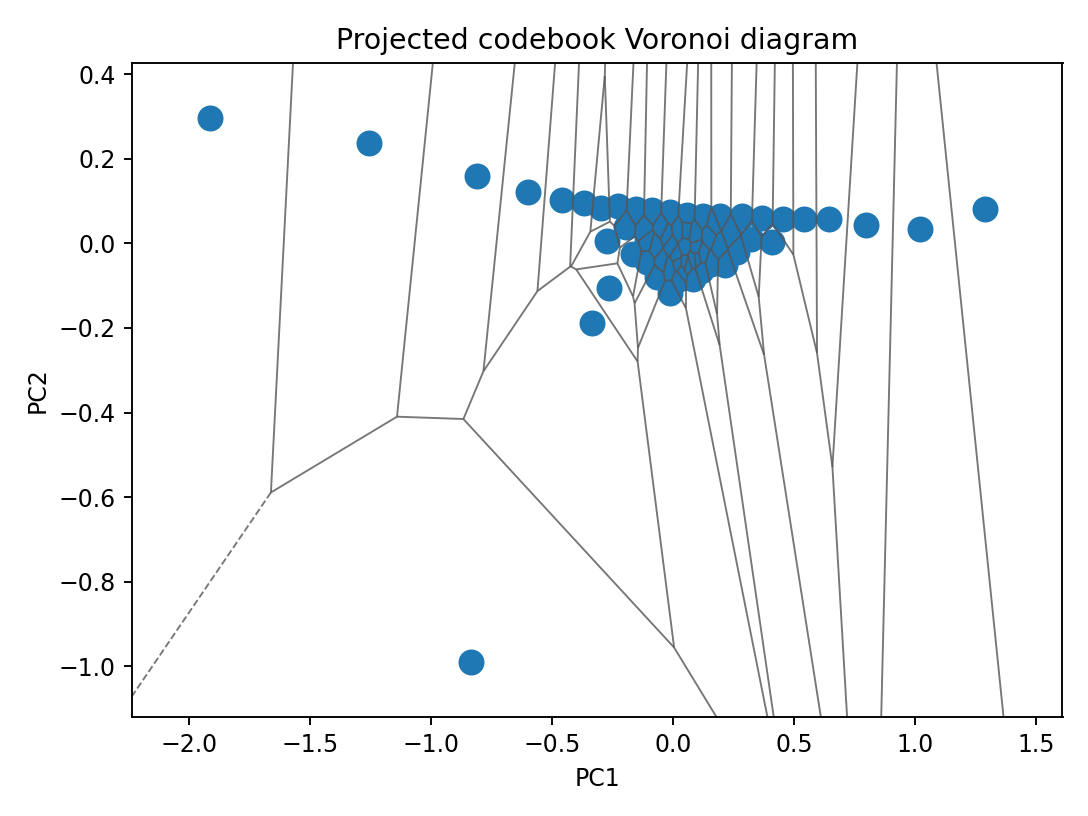

In [6]:
plot_names = [
    "codebook_projection.png",
    "codebook_usage_projection.png",
    "vix_bucket_code_usage.png",
    "token_trajectory_examples.png",
    "codebook_voronoi.png",
    "codebook_nearest_region.png",
]
rows = []
for plot_name in plot_names:
    plot_path = OUTPUT_DIR / plot_name
    rows.append(
        {
            "plot": plot_name,
            "path": display_path(plot_path),
            "exists": repo_path(plot_path).exists(),
        }
    )
display(pd.DataFrame(rows))
for plot_name in plot_names:
    plot_path = repo_path(OUTPUT_DIR / plot_name)
    if plot_path.exists():
        display(Markdown(f"### `{plot_name}`"))
        display(Image(filename=str(plot_path)))

## Interpretation

RVQ q2 was evaluated on research branches and is not part of the public baseline.
